In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import gc
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)

print("Libraries imported successfully")

Libraries imported successfully


In [5]:
train_transaction = pd.read_csv(
    "data/train_transaction.csv"
)

train_identity = pd.read_csv(
    "data/train_identity.csv"
)

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)

Transaction shape: (590540, 394)
Identity shape: (144233, 41)


In [6]:
print("Transaction Data:")
display(train_transaction.head())

print("\nIdentity Data:")
display(train_identity.head())

Transaction Data:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,1.0,1.0,1.0,1.0,38.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,50.0,1758.0,925.0,0.0,354.0,0.0,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Identity Data:


,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [7]:
print("Fraud Counts:")
print(train_transaction["isFraud"].value_counts())

print("\nFraud Percentage:")
print(
    train_transaction["isFraud"]
    .value_counts(normalize=True)
    .mul(100)
)

Fraud Counts:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


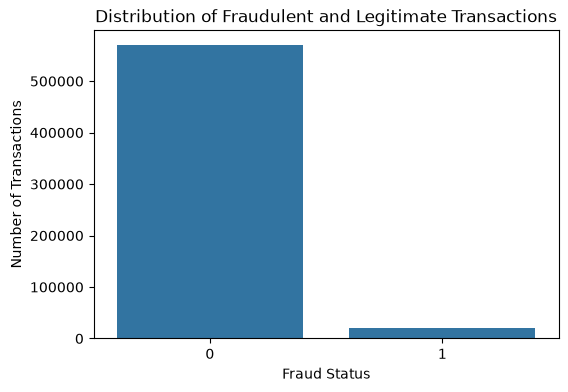

In [8]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=train_transaction,
    x="isFraud"
)

plt.title("Distribution of Fraudulent and Legitimate Transactions")
plt.xlabel("Fraud Status")
plt.ylabel("Number of Transactions")

plt.show()

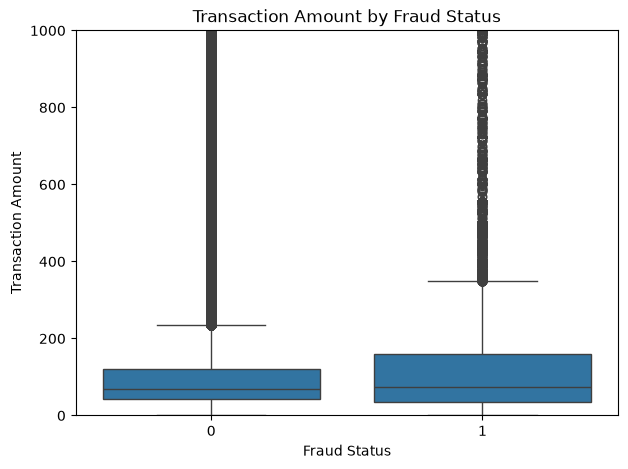

In [9]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=train_transaction,
    x="isFraud",
    y="TransactionAmt"
)

plt.ylim(0, 1000)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud Status")
plt.ylabel("Transaction Amount")

plt.show()

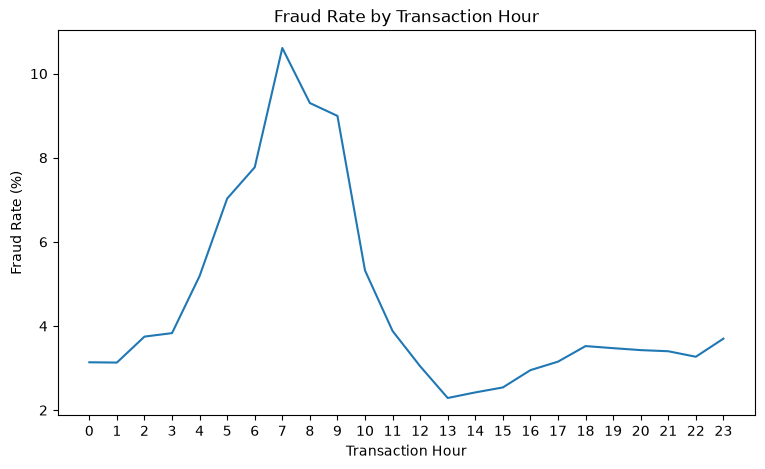

In [10]:
train_transaction["TransactionHour"] = (
    (train_transaction["TransactionDT"] // 3600) % 24
).astype("int8")

hourly_fraud = (
    train_transaction
    .groupby("TransactionHour")["isFraud"]
    .mean()
    .mul(100)
)

plt.figure(figsize=(9, 5))
plt.plot(hourly_fraud.index, hourly_fraud.values)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))

plt.show()

In [11]:
missing_percentage = (
    train_transaction.isnull().mean() * 100
)

print("Columns with more than 50% missing values:",
      (missing_percentage > 50).sum())

print("Columns with more than 90% missing values:",
      (missing_percentage > 90).sum())

Columns with more than 50% missing values: 174
Columns with more than 90% missing values: 2


In [12]:
y = train_transaction["isFraud"].copy()

X = train_transaction.drop(
    columns=["isFraud", "TransactionID"]
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (590540, 393)
y shape: (590540,)


In [13]:
high_missing_cols = X.columns[
    X.isnull().mean() > 0.90
].tolist()

print("Columns to remove:", len(high_missing_cols))
print(high_missing_cols)

X = X.drop(columns=high_missing_cols)

print("X shape after removal:", X.shape)

Columns to remove: 2
['dist2', 'D7']
X shape after removal: (590540, 391)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining fraud rate:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting fraud rate:")
print(y_test.value_counts(normalize=True) * 100)

Training shape: (472432, 391)
Testing shape: (118108, 391)

Training fraud rate:
isFraud
0    96.501084
1     3.498916
Name: proportion, dtype: float64

Testing fraud rate:
isFraud
0    96.50066
1     3.49934
Name: proportion, dtype: float64


In [15]:
train_missing = X_train.isnull().mean() * 100

high_missing_cols = train_missing[
    train_missing > 90
].index.tolist()

print("Columns to remove:", len(high_missing_cols))
print(high_missing_cols)

Columns to remove: 0
[]


In [16]:
numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))

Numerical features: 376
Categorical features: 14


In [17]:
other_cols = X_train.columns.difference(
    numerical_cols + categorical_cols
)

print("Other columns:", len(other_cols))
print(other_cols.tolist())

print("\nData types:")
print(X_train[other_cols].dtypes)

Other columns: 1
['TransactionHour']

Data types:
TransactionHour    int8
dtype: object


In [18]:
numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", len(numerical_cols))
print("Categorical features:", len(categorical_cols))
print("Total features:", len(numerical_cols) + len(categorical_cols))

Numerical features: 377
Categorical features: 14
Total features: 391


In [19]:
for col in numerical_cols:
    median_value = X_train[col].median()

    X_train[col] = X_train[col].fillna(median_value)
    X_test[col] = X_test[col].fillna(median_value)

print("Training numerical missing values:",
      X_train[numerical_cols].isnull().sum().sum())

print("Testing numerical missing values:",
      X_test[numerical_cols].isnull().sum().sum())

Training numerical missing values: 0
Testing numerical missing values: 0


In [20]:
for col in categorical_cols:
    X_train[col] = X_train[col].fillna("Missing")
    X_test[col] = X_test[col].fillna("Missing")

print(
    "Training categorical missing values:",
    X_train[categorical_cols].isnull().sum().sum()
)

print(
    "Testing categorical missing values:",
    X_test[categorical_cols].isnull().sum().sum()
)

Training categorical missing values: 0
Testing categorical missing values: 0


In [21]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
    dtype=np.float32
)

X_train[categorical_cols] = encoder.fit_transform(
    X_train[categorical_cols]
)

X_test[categorical_cols] = encoder.transform(
    X_test[categorical_cols]
)

print("Categorical encoding completed")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Categorical encoding completed
X_train shape: (472432, 391)
X_test shape: (118108, 391)


In [22]:
X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)

import gc
gc.collect()

print("X_train dtype:", X_train.dtypes.unique())
print("X_test dtype:", X_test.dtypes.unique())

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train dtype: [dtype('float32')]
X_test dtype: [dtype('float32')]
X_train shape: (472432, 391)
X_test shape: (118108, 391)


In [23]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=500,
    random_state=42,
    n_jobs=-1
)

logistic_model.fit(X_train, y_train)

print("Logistic Regression training completed")

Logistic Regression training completed


In [24]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:")
print(roc_auc_score(y_test, y_prob))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.55      0.70    113975
           1       0.04      0.51      0.07      4133

    accuracy                           0.55    118108
   macro avg       0.50      0.53      0.39    118108
weighted avg       0.94      0.55      0.68    118108

ROC-AUC Score:
0.5420990867008234

PR-AUC Score:
0.039160371950525956

Confusion Matrix:
[[63086 50889]
 [ 2041  2092]]


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed")

Random Forest training completed


In [26]:
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, rf_prob))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, rf_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98    113975
           1       0.40      0.69      0.51      4133

    accuracy                           0.95    118108
   macro avg       0.69      0.83      0.74    118108
weighted avg       0.97      0.95      0.96    118108


ROC-AUC Score:
0.9301168235570654

PR-AUC Score:
0.6366436328731453

Confusion Matrix:
[[109666   4309]
 [  1267   2866]]


In [27]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [28]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost training completed")

XGBoost training completed


In [29]:
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred))

print("\nROC-AUC Score:")
print(roc_auc_score(y_test, xgb_prob))

print("\nPR-AUC Score:")
print(average_precision_score(y_test, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.98    113975
           1       0.43      0.82      0.57      4133

    accuracy                           0.96    118108
   macro avg       0.71      0.89      0.77    118108
weighted avg       0.97      0.96      0.96    118108


ROC-AUC Score:
0.963930144158793

PR-AUC Score:
0.7760789653335654

Confusion Matrix:
[[109494   4481]
 [   726   3407]]


In [30]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob),
        average_precision_score(y_test, rf_prob),
        average_precision_score(y_test, xgb_prob)
    ]
})

model_comparison.sort_values(
    by="PR-AUC",
    ascending=False
)

,Model,ROC-AUC,PR-AUC
2,XGBoost,0.963930,0.776079
1,Random Forest,0.930117,0.636644
0,Logistic Regression,0.542099,0.039160


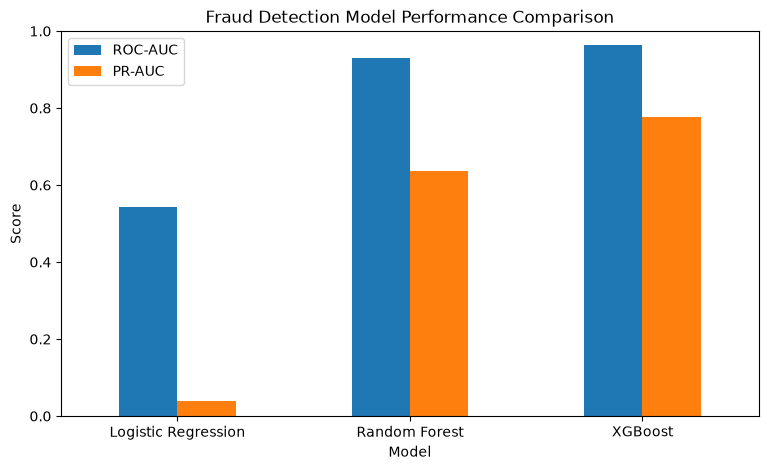

In [31]:
comparison_plot = model_comparison.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Fraud Detection Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)

plt.show()

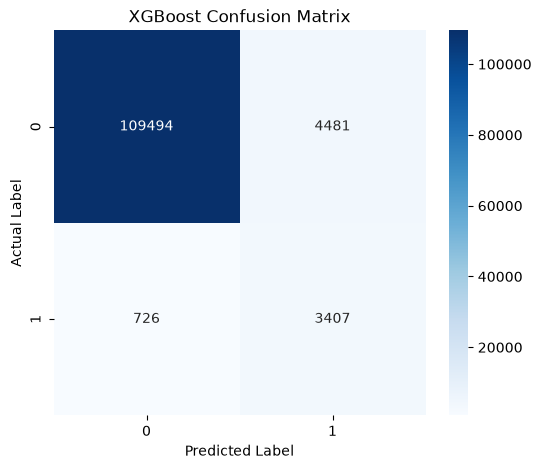

In [32]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    confusion_matrix(y_test, xgb_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

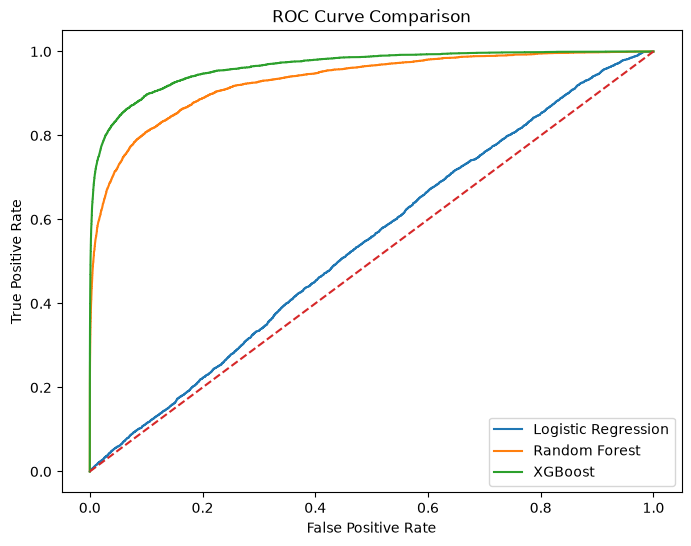

In [33]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.show()

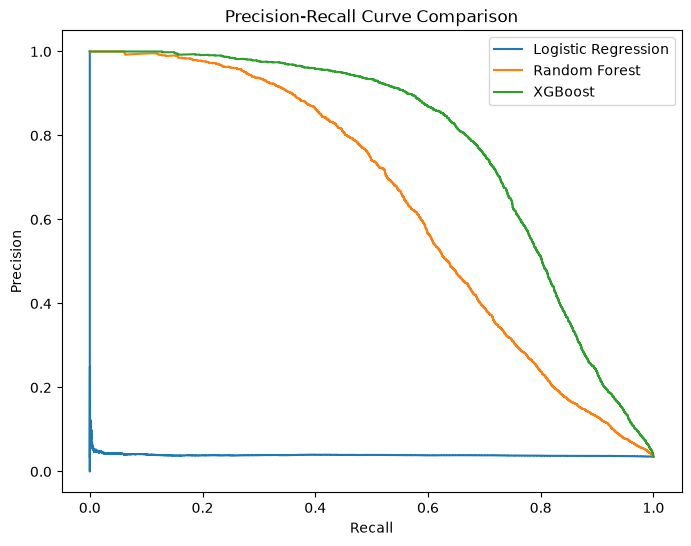

In [34]:
from sklearn.metrics import precision_recall_curve

lr_precision, lr_recall, _ = precision_recall_curve(y_test, y_prob)
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_prob)
xgb_precision, xgb_recall, _ = precision_recall_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(lr_recall, lr_precision, label="Logistic Regression")
plt.plot(rf_recall, rf_precision, label="Random Forest")
plt.plot(xgb_recall, xgb_precision, label="XGBoost")

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()

plt.show()

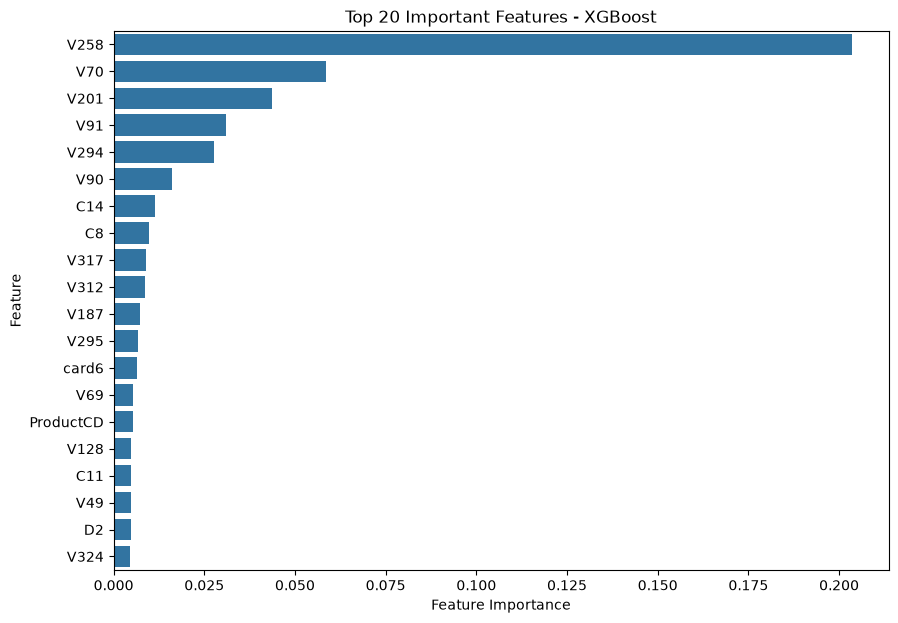

In [35]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

top_features = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features - XGBoost")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [38]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Final Training Shape:", X_train_final.shape)
print("Validation Shape:", X_val.shape)
print("Test Shape:", X_test.shape)

print("\nTraining Fraud Rate:")
print(y_train_final.value_counts(normalize=True) * 100)

print("\nValidation Fraud Rate:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest Fraud Rate:")
print(y_test.value_counts(normalize=True) * 100)

Final Training Shape: (377945, 391)
Validation Shape: (94487, 391)
Test Shape: (118108, 391)

Training Fraud Rate:
isFraud
0    96.501078
1     3.498922
Name: proportion, dtype: float64

Validation Fraud Rate:
isFraud
0    96.501106
1     3.498894
Name: proportion, dtype: float64

Test Fraud Rate:
isFraud
0    96.50066
1     3.49934
Name: proportion, dtype: float64


In [39]:
from xgboost import XGBClassifier

xgb_final_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_final_model.fit(
    X_train_final,
    y_train_final
)

print("Final XGBoost training completed")

Final XGBoost training completed


In [40]:
import numpy as np
import pandas as pd

from sklearn.metrics import f1_score

val_prob = xgb_final_model.predict_proba(
    X_val
)[:, 1]

thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

val_f1_scores = []

for threshold in thresholds:
    val_pred = (
        val_prob >= threshold
    ).astype(int)

    score = f1_score(
        y_val,
        val_pred
    )

    val_f1_scores.append(score)

validation_threshold_results = pd.DataFrame({
    "Threshold": thresholds,
    "Validation F1 Score": val_f1_scores
})

validation_threshold_results

,Threshold,Validation F1 Score
0,0.10,0.553976
1,0.15,0.626645
2,0.20,0.647107
3,0.25,0.646500
4,0.30,0.641157
5,0.35,0.629447
6,0.40,0.617395
7,0.45,0.606158
8,0.50,0.588837
9,0.55,0.570652


In [41]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

best_val_index = validation_threshold_results[
    "Validation F1 Score"
].idxmax()

best_threshold = validation_threshold_results.loc[
    best_val_index,
    "Threshold"
]

test_prob = xgb_final_model.predict_proba(
    X_test
)[:, 1]

final_test_pred = (
    test_prob >= best_threshold
).astype(int)

print("Selected Validation Threshold:", best_threshold)

print("\nFinal Test Classification Report:")
print(
    classification_report(
        y_test,
        final_test_pred
    )
)

print("\nFinal Test ROC-AUC:")
print(
    roc_auc_score(
        y_test,
        test_prob
    )
)

print("\nFinal Test PR-AUC:")
print(
    average_precision_score(
        y_test,
        test_prob
    )
)

print("\nFinal Test Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        final_test_pred
    )
)

Selected Validation Threshold: 0.20000000000000004

Final Test Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    113975
           1       0.70      0.60      0.65      4133

    accuracy                           0.98    118108
   macro avg       0.84      0.79      0.82    118108
weighted avg       0.98      0.98      0.98    118108


Final Test ROC-AUC:
0.930684232702009

Final Test PR-AUC:
0.6793890846045428

Final Test Confusion Matrix:
[[112937   1038]
 [  1670   2463]]


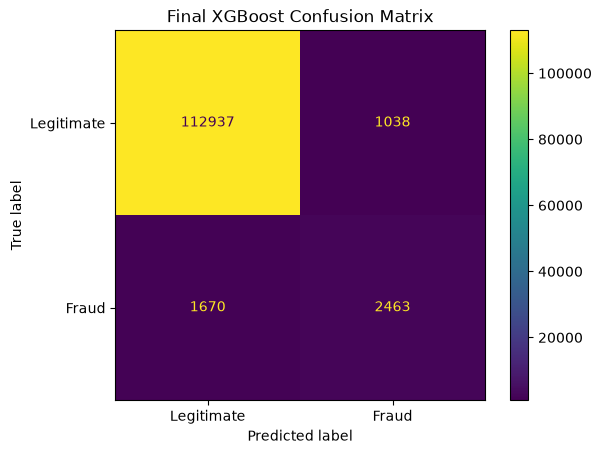

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_test_pred,
    display_labels=[
        "Legitimate",
        "Fraud"
    ],
    values_format="d"
)

plt.title(
    "Final XGBoost Confusion Matrix"
)

plt.show()

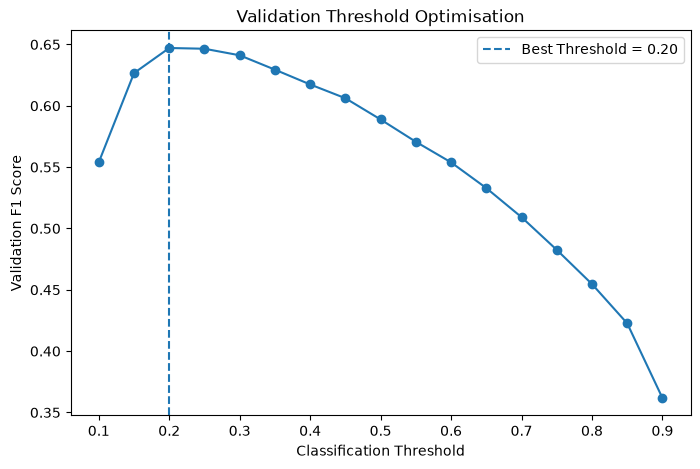

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    validation_threshold_results["Threshold"],
    validation_threshold_results["Validation F1 Score"],
    marker="o"
)

plt.axvline(
    x=best_threshold,
    linestyle="--",
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.title("Validation Threshold Optimisation")
plt.xlabel("Classification Threshold")
plt.ylabel("Validation F1 Score")
plt.legend()

plt.show()

In [44]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Fraud Precision",
        "Fraud Recall",
        "Fraud F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Selected Threshold"
    ],
    "Score": [
        accuracy_score(y_test, final_test_pred),
        precision_score(y_test, final_test_pred),
        recall_score(y_test, final_test_pred),
        f1_score(y_test, final_test_pred),
        roc_auc_score(y_test, test_prob),
        average_precision_score(y_test, test_prob),
        best_threshold
    ]
})

final_results

,Metric,Score
0,Accuracy,0.977072
1,Fraud Precision,0.703513
2,Fraud Recall,0.595935
3,Fraud F1 Score,0.645271
4,ROC-AUC,0.930684
5,PR-AUC,0.679389
6,Selected Threshold,0.200000


In [45]:
import joblib

joblib.dump(
    xgb_final_model,
    "fraud_detection_xgboost_model.pkl"
)

print("Final XGBoost model saved successfully.")

Final XGBoost model saved successfully.


In [46]:
model_metadata = {
    "threshold": best_threshold,
    "feature_columns": X_train_final.columns.tolist()
}

joblib.dump(
    model_metadata,
    "fraud_detection_metadata.pkl"
)

print("Model metadata saved successfully.")
print("Selected threshold:", best_threshold)
print("Number of features:", len(X_train_final.columns))

Model metadata saved successfully.
Selected threshold: 0.20000000000000004
Number of features: 391


In [51]:
X_test.head(100).to_csv(
    "sample_transactions.csv",
    index=False
)

print("Sample CSV created successfully.")

Sample CSV created successfully.


In [52]:
fraud_test_samples = X_test[y_test == 1].head(20)

fraud_test_samples.to_csv(
    "fraud_test_samples.csv",
    index=False
)

print("Fraud test CSV created successfully.")
print("Number of fraud samples:", len(fraud_test_samples))

Fraud test CSV created successfully.
Number of fraud samples: 20
